# VGG16 NTW Dataset — Participant-Level Evaluation (Corrected)

This notebook runs two VGG16 experiments on the combined **NEUROCON–Tao Wu (NTW) MRI dataset**:

1. Frozen VGG16 backbone
2. Fine-tuned VGG16 backbone

The split is participant-disjoint:

- All 40 MRI slices from one participant stay in the same split.
- No participant appears in more than one subset.
- The model is trained on slices from training participants.
- Slice probabilities are averaged to create one participant probability.
- Metrics are calculated on completely unseen test participants.

The notebook saves:

- Participant split CSV files
- Model summaries and parameter counts
- Accuracy, loss, and AUC graphs
- Slice-level predictions
- Participant-level predictions
- Accuracy, precision, recall, specificity, F1-score, and ROC-AUC
- Classification reports
- Participant-level confusion matrices
- Participant-level ROC curves
- Compressed NPZ files
- Corrected Grad-CAM examples
- Frozen-versus-fine-tuned comparison

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:


import os, json, random, shutil, zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# =========================
# USER PATHS
# =========================
ZIP_PATH = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_NTW_patient_level/VGG16_NTW_patient_level_dataset_here/Parkinson_dataset_2.zip"
UNZIP_DIR = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_NTW_patient_level/VGG16_NTW_patient_level_dataset_unzip_here"
SAVE_DIR = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_NTW_patient_level/VGG16_NTW_patient_level_data_save_here"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

FROZEN_EPOCHS = 35
WARMUP_EPOCHS = 10
FINE_TUNE_EPOCHS = 25
FINE_TUNE_LAST_LAYERS = 8

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
print("Results will be saved to:", SAVE_DIR)

Results will be saved to: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_NTW_patient_level/VGG16_NTW_patient_level_data_save_here


In [4]:
# =========================
# UNZIP AND FIND DATASET ROOT
# =========================
if not Path(ZIP_PATH).exists():
    raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")

if Path(UNZIP_DIR).exists():
    shutil.rmtree(UNZIP_DIR)
Path(UNZIP_DIR).mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(UNZIP_DIR)

def find_dataset_root(root):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for candidate in candidates:
        if (candidate / "healthy_control").is_dir() and (candidate / "parkinson").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find a folder containing both healthy_control and parkinson."
    )

DATASET_ROOT = find_dataset_root(UNZIP_DIR)
print("Dataset root:", DATASET_ROOT)

Dataset root: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_NTW_patient_level/VGG16_NTW_patient_level_dataset_unzip_here/sagittal_images


In [5]:
# =========================
# BUILD METADATA
# =========================
valid_ext = {".png", ".jpg", ".jpeg", ".bmp"}
class_map = {"healthy_control": 0, "parkinson": 1}

records = []
for class_name, label in class_map.items():
    for image_path in (DATASET_ROOT / class_name).rglob("*"):
        if image_path.is_file() and image_path.suffix.lower() in valid_ext:
            records.append({
                "filepath": str(image_path),
                "label": label,
                "class_name": class_name,
                "patient_id": image_path.parent.name,
                "source_dataset": image_path.parent.parent.name,
            })

df = pd.DataFrame(records).sort_values("filepath").reset_index(drop=True)

if df.empty:
    raise ValueError("No images were found.")

print("Total images:", len(df))
print(df["class_name"].value_counts())
print("\nParticipants by class:")
print(df.groupby("class_name")["patient_id"].nunique())
print("\nImages by source:")
print(df["source_dataset"].value_counts())
print("\nTotal participants:", df["patient_id"].nunique())
print("\nImages per participant:")
display(df.groupby("patient_id").size().describe().to_frame("count"))

if len(df) != 3320:
    print(f"Warning: expected 3320 images, found {len(df)}")
if df["patient_id"].nunique() != 83:
    print(f"Warning: expected 83 participants, found {df['patient_id'].nunique()}")
if not (df.groupby("patient_id").size() == 40).all():
    print("Warning: not every participant has exactly 40 images.")

df.to_csv(Path(SAVE_DIR) / "NTW_complete_metadata.csv", index=False)

Total images: 3320
class_name
parkinson          1880
healthy_control    1440
Name: count, dtype: int64

Participants by class:
class_name
healthy_control    36
parkinson          47
Name: patient_id, dtype: int64

Images by source:
source_dataset
NEUROCON    1720
Tao_Wu      1600
Name: count, dtype: int64

Total participants: 83

Images per participant:


,count
count,83.0
mean,40.0
std,0.0
min,40.0
25%,40.0
50%,40.0
75%,40.0
max,40.0


In [6]:
# =========================
# PARTICIPANT-DISJOINT SPLIT
# =========================
participant_table = (
    df.groupby("patient_id", as_index=False)
      .agg(
          label=("label", "first"),
          class_name=("class_name", "first"),
          source_dataset=("source_dataset", "first"),
          number_of_images=("filepath", "size"),
      )
)

train_participants, temp_participants = train_test_split(
    participant_table,
    test_size=VAL_RATIO + TEST_RATIO,
    random_state=SEED,
    stratify=participant_table["label"],
)

relative_test_size = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

val_participants, test_participants = train_test_split(
    temp_participants,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=temp_participants["label"],
)

train_ids = set(train_participants["patient_id"])
val_ids = set(val_participants["patient_id"])
test_ids = set(test_participants["patient_id"])

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

train_df = df[df["patient_id"].isin(train_ids)].copy()
val_df = df[df["patient_id"].isin(val_ids)].copy()
test_df = df[df["patient_id"].isin(test_ids)].copy()

def show_split(name, participant_frame, image_frame):
    print(f"\n{name}")
    print("Participants:", len(participant_frame))
    print("Images:", len(image_frame))
    print(participant_frame["class_name"].value_counts())

show_split("Train", train_participants, train_df)
show_split("Validation", val_participants, val_df)
show_split("Test", test_participants, test_df)

train_participants.to_csv(Path(SAVE_DIR) / "participant_train_split.csv", index=False)
val_participants.to_csv(Path(SAVE_DIR) / "participant_validation_split.csv", index=False)
test_participants.to_csv(Path(SAVE_DIR) / "participant_test_split.csv", index=False)

train_df.to_csv(Path(SAVE_DIR) / "participant_train_images.csv", index=False)
val_df.to_csv(Path(SAVE_DIR) / "participant_validation_images.csv", index=False)
test_df.to_csv(Path(SAVE_DIR) / "participant_test_images.csv", index=False)

print("\nParticipant split completed successfully.")


Train
Participants: 58
Images: 2320
class_name
parkinson          33
healthy_control    25
Name: count, dtype: int64

Validation
Participants: 12
Images: 480
class_name
parkinson          7
healthy_control    5
Name: count, dtype: int64

Test
Participants: 13
Images: 520
class_name
parkinson          7
healthy_control    6
Name: count, dtype: int64

Participant split completed successfully.


The code above performs the participant-disjoint split using `train_test_split` from `sklearn.model_selection`:

1.  **`participant_table`**: Groups the main DataFrame `df` by `patient_id` to create a summary table for each participant, including their label, class name, source dataset, and number of images.
2.  **First `train_test_split`**: Splits `participant_table` into `train_participants` and `temp_participants`. `test_size` is the combined `VAL_RATIO + TEST_RATIO` (0.15 + 0.15 = 0.30), ensuring 70% for training and 30% for a temporary validation/test pool. `stratify` ensures an even distribution of labels (healthy/parkinson).
3.  **`relative_test_size`**: Calculates the proportion of the `temp_participants` that should go into the test set (`TEST_RATIO / (VAL_RATIO + TEST_RATIO)` which is 0.15 / 0.30 = 0.5).
4.  **Second `train_test_split`**: Splits `temp_participants` into `val_participants` and `test_participants` using the `relative_test_size`.
5.  **`train_ids`, `val_ids`, `test_ids`**: Extracts the unique patient IDs for each split.
6.  **`assert` statements**: Verifies that there is no overlap between the participant IDs across the splits, confirming they are disjoint.
7.  **`train_df`, `val_df`, `test_df`**: Filters the original full image DataFrame `df` based on the participant IDs to create the image DataFrames for each split.
8.  **`show_split` function**: A helper function to print the number of participants and images, and the class distribution for each split.
9.  **CSV saving**: Saves the participant and image DataFrames for each split to CSV files in the `SAVE_DIR`.

In [7]:
# =========================
# TF.DATA PIPELINE
# =========================
AUTOTUNE = tf.data.AUTOTUNE

augmentation = keras.Sequential([
    layers.RandomRotation(0.04, fill_mode="nearest", seed=SEED),
    layers.RandomZoom(0.10, fill_mode="nearest", seed=SEED),
    layers.RandomTranslation(0.05, 0.05, fill_mode="nearest", seed=SEED),
], name="augmentation")

def load_image(path, label, training=False):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    if training:
        image = augmentation(image, training=True)

    image = preprocess_input(image)
    return image, tf.cast(label, tf.float32)

def make_dataset(frame, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (
            frame["filepath"].astype(str).values,
            frame["label"].astype("float32").values,
        )
    )

    if training:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda p, y: load_image(p, y, training),
        num_parallel_calls=AUTOTUNE,
    )
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

In [8]:
# =========================
# MODEL AND UTILITY FUNCTIONS
# =========================
def build_vgg16_model(model_name):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="mri_input")

    backbone = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    backbone.trainable = False

    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dense(256, activation="relu", name="head_dense")(x)
    x = layers.Dropout(0.50, name="head_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    return keras.Model(inputs, outputs, name=model_name), backbone

def compile_model(model, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )

def save_summary(model, path):
    lines = []
    model.summary(print_fn=lines.append)
    Path(path).write_text("\n".join(lines), encoding="utf-8")
    print("\n".join(lines))

def get_parameter_counts(model):
    trainable = sum(int(tf.keras.backend.count_params(w)) for w in model.trainable_weights)
    non_trainable = sum(int(tf.keras.backend.count_params(w)) for w in model.non_trainable_weights)
    return pd.DataFrame([{
        "model": model.name,
        "total_parameters": trainable + non_trainable,
        "trainable_parameters": trainable,
        "non_trainable_parameters": non_trainable,
    }])

def combine_histories(*histories):
    merged = {}
    for h in histories:
        for key, values in h.history.items():
            merged.setdefault(key, [])
            merged[key].extend([float(v) for v in values])
    return merged

def save_history(history, folder, prefix):
    pd.DataFrame(history).to_csv(Path(folder) / f"{prefix}_history.csv", index=False)
    with open(Path(folder) / f"{prefix}_history.json", "w") as f:
        json.dump(history, f, indent=2)

def plot_history(history, folder, title_prefix, prefix, fine_tune_start=None):
    epochs = np.arange(1, len(history["loss"]) + 1)

    for metric, ylabel, suffix in [
        ("accuracy", "Accuracy", "accuracy"),
        ("loss", "Binary Cross-Entropy Loss", "loss"),
        ("auc", "ROC-AUC", "auc"),
    ]:
        plt.figure(figsize=(9, 6))
        plt.plot(epochs, history[metric], linewidth=2, label=f"Training {ylabel}")
        plt.plot(epochs, history[f"val_{metric}"], linewidth=2, label=f"Validation {ylabel}")

        if fine_tune_start is not None:
            plt.axvline(
                fine_tune_start,
                linestyle="--",
                linewidth=1.5,
                label="Fine-Tuning Start",
            )

        plt.title(f"{title_prefix} {ylabel}", fontsize=15, fontweight="bold")
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        if metric in ("accuracy", "auc"):
            plt.ylim(0, 1.02)
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.savefig(Path(folder) / f"{prefix}_{suffix}.png", dpi=300, bbox_inches="tight")
        plt.show()

def get_backbone(model):
    for layer in model.layers:
        if isinstance(layer, keras.Model) and layer.name.startswith("vgg16"):
            return layer
    raise ValueError("VGG16 backbone not found inside model.")

In [9]:
# =========================
# PARTICIPANT-LEVEL EVALUATION
# =========================
def evaluate_participant_model(model, dataset, frame, folder, display_name, prefix):
    folder = Path(folder)

    slice_probs = model.predict(dataset, verbose=1).ravel()

    slice_results = frame[[
        "filepath", "patient_id", "source_dataset", "class_name", "label"
    ]].copy()
    slice_results["slice_probability_parkinson"] = slice_probs
    slice_results["slice_prediction"] = (slice_probs >= 0.5).astype(int)

    slice_results.to_csv(folder / f"{prefix}_slice_predictions.csv", index=False)

    participant_results = (
        slice_results.groupby(
            ["patient_id", "source_dataset", "class_name", "label"],
            as_index=False,
        )
        .agg(
            participant_probability=("slice_probability_parkinson", "mean"),
            number_of_slices=("filepath", "size"),
        )
    )

    participant_results["participant_prediction"] = (
        participant_results["participant_probability"] >= 0.5
    ).astype(int)

    y_true = participant_results["label"].to_numpy(dtype=int)
    y_score = participant_results["participant_probability"].to_numpy(dtype=float)
    y_pred = participant_results["participant_prediction"].to_numpy(dtype=int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "Model": display_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "F1_Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "Test_Participants": len(y_true),
        "Test_Slices": len(slice_results),
    }

    metrics_df = pd.DataFrame([metrics])
    display(metrics_df)
    display(participant_results)

    metrics_df.to_csv(folder / f"{prefix}_participant_metrics.csv", index=False)
    participant_results.to_csv(
        folder / f"{prefix}_participant_predictions.csv",
        index=False,
    )

    report = classification_report(
        y_true, y_pred,
        target_names=["Healthy Control", "Parkinson"],
        digits=4, zero_division=0,
    )
    print(report)
    (folder / f"{prefix}_participant_classification_report.txt").write_text(report)

    # Confusion matrix
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{display_name}\nParticipant-Level Confusion Matrix", fontweight="bold")
    plt.xticks([0, 1], ["Healthy Control", "Parkinson"])
    plt.yticks([0, 1], ["Healthy Control", "Parkinson"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    threshold = cm.max() / 2
    for i in range(2):
        for j in range(2):
            plt.text(
                j, i, cm[i, j],
                ha="center", va="center",
                fontsize=15, fontweight="bold",
                color="white" if cm[i, j] > threshold else "black",
            )

    plt.tight_layout()
    plt.savefig(
        folder / f"{prefix}_participant_confusion_matrix.png",
        dpi=300, bbox_inches="tight",
    )
    plt.show()

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    plt.figure(figsize=(7, 6))
    plt.plot(
        fpr, tpr, linewidth=2.5,
        label=f"{display_name} (AUC={metrics['ROC_AUC']:.4f})",
    )
    plt.plot([0, 1], [0, 1], "--", label="Random Classifier")
    plt.title(f"{display_name}\nParticipant-Level ROC Curve", fontweight="bold")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(alpha=0.25)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(
        folder / f"{prefix}_participant_roc_curve.png",
        dpi=300, bbox_inches="tight",
    )
    plt.show()

    np.savez_compressed(
        folder / f"{prefix}_participant_predictions_roc.npz",
        y_true=y_true,
        y_score=y_score,
        y_pred=y_pred,
        fpr=fpr,
        tpr=tpr,
        thresholds=thresholds,
        roc_auc=np.array([metrics["ROC_AUC"]]),
        patient_ids=participant_results["patient_id"].astype(str).to_numpy(),
        source_datasets=participant_results["source_dataset"].astype(str).to_numpy(),
        class_names=participant_results["class_name"].astype(str).to_numpy(),
    )

    return metrics, slice_results, participant_results

In [10]:
# =========================
# CORRECTED GRAD-CAM
# =========================
def make_gradcam_heatmap(model, image_batch):
    backbone = get_backbone(model)
    last_conv = backbone.get_layer("block5_conv3")

    conv_model = keras.Model(
        inputs=backbone.input,
        outputs=[last_conv.output, backbone.output],
    )

    with tf.GradientTape() as tape:
        conv_output, backbone_output = conv_model(image_batch, training=False)

        x = model.get_layer("gap")(backbone_output)
        x = model.get_layer("head_bn")(x, training=False)
        x = model.get_layer("head_dense")(x)
        x = model.get_layer("head_dropout")(x, training=False)
        prediction = model.get_layer("prediction")(x)

        target = prediction[:, 0]

    gradients = tape.gradient(target, conv_output)
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = tf.reduce_sum(conv_output * pooled_gradients, axis=-1)
    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)
    if float(max_value.numpy()) > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy(), float(prediction.numpy()[0, 0])

def create_gradcam(image_path, model, output_path, title):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(image_rgb, IMG_SIZE)

    batch = np.expand_dims(resized.astype(np.float32), axis=0)
    batch = preprocess_input(batch)

    heatmap, probability = make_gradcam_heatmap(model, batch)

    heatmap_uint8 = np.uint8(255 * heatmap)
    color_map = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    color_map = cv2.cvtColor(color_map, cv2.COLOR_BGR2RGB)
    color_map = cv2.resize(color_map, (resized.shape[1], resized.shape[0]))

    overlay = np.clip(0.60 * resized + 0.40 * color_map, 0, 255).astype(np.uint8)
    predicted = "Parkinson" if probability >= 0.5 else "Healthy Control"

    plt.figure(figsize=(13, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(resized)
    plt.title("Original MRI")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Overlay\nPrediction: {predicted} ({probability:.4f})")
    plt.axis("off")

    plt.suptitle(title, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

def generate_participant_gradcams(
    model,
    slice_results,
    participant_results,
    folder,
    prefix,
):
    gradcam_dir = Path(folder) / "gradcam"
    gradcam_dir.mkdir(parents=True, exist_ok=True)

    correct_participants = participant_results[
        participant_results["label"]
        == participant_results["participant_prediction"]
    ].copy()

    healthy_participants = (
        correct_participants[correct_participants["label"] == 0]
        .sort_values("participant_probability", ascending=True)
        .head(1)
    )

    parkinson_participants = (
        correct_participants[correct_participants["label"] == 1]
        .sort_values("participant_probability", ascending=False)
        .head(3)
    )

    selected_participants = pd.concat(
        [healthy_participants, parkinson_participants],
        ignore_index=True,
    )

    records = []

    for _, participant_row in selected_participants.iterrows():
        patient_id = participant_row["patient_id"]
        true_label = int(participant_row["label"])

        participant_slices = slice_results[
            slice_results["patient_id"] == patient_id
        ].copy()

        if true_label == 0:
            selected_slice = participant_slices.sort_values(
                "slice_probability_parkinson", ascending=True
            ).iloc[0]
            class_name = "Healthy_Control"
        else:
            selected_slice = participant_slices.sort_values(
                "slice_probability_parkinson", ascending=False
            ).iloc[0]
            class_name = "Parkinson"

        out_file = gradcam_dir / f"{prefix}_{class_name}_{patient_id}.png"

        create_gradcam(
            selected_slice["filepath"],
            model,
            out_file,
            f"{prefix.replace('_', ' ')} — {class_name.replace('_', ' ')}",
        )

        records.append({
            "patient_id": patient_id,
            "true_class": participant_row["class_name"],
            "participant_probability": participant_row["participant_probability"],
            "selected_slice": selected_slice["filepath"],
            "output_file": str(out_file),
        })

    pd.DataFrame(records).to_csv(
        gradcam_dir / f"{prefix}_gradcam_examples.csv",
        index=False,
    )

## Experiment 1 — Frozen VGG16 Backbone

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_NTW_Participant_Frozen"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mri_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)    │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 256)            │       131,328 │
├─────────────────────────────────┼───

,model,total_parameters,trainable_parameters,non_trainable_parameters
0,VGG16_NTW_Participant_Frozen,14848321,132609,14715712


Epoch 1/35
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5510 - auc: 0.5560 - loss: 0.8513
Epoch 1: val_auc improved from None to 0.66742, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_NTW_patient_level/VGG16_NTW_patient_level_data_save_here/VGG16_NTW_Participant_Frozen/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_NTW_patient_level/VGG16_NTW_patient_level_data_save_here/VGG16_NTW_Participant_Frozen/best_model.keras
145/145 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.5569 - auc: 0.5608 - loss: 0.8320 - val_accuracy: 0.5979 - val_auc: 0.6674 - val_loss: 0.6544 - learning_rate: 1.0000e-04
Epoch 2/35
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6175 - auc: 0.6432 - loss: 0.7176
Epoch 2: val_auc did not improve from 0.66742
145/145 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.6116 - auc: 0.6335 - loss: 0.732

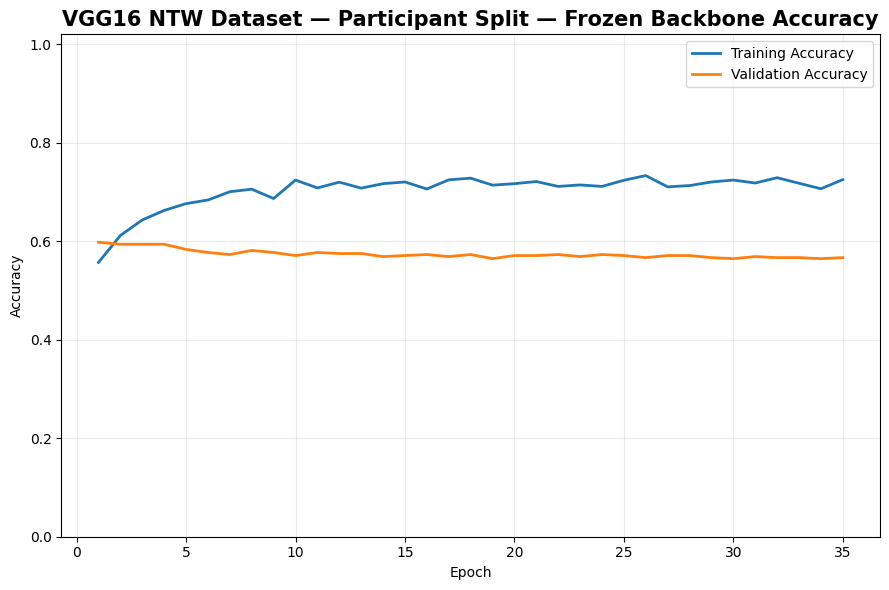

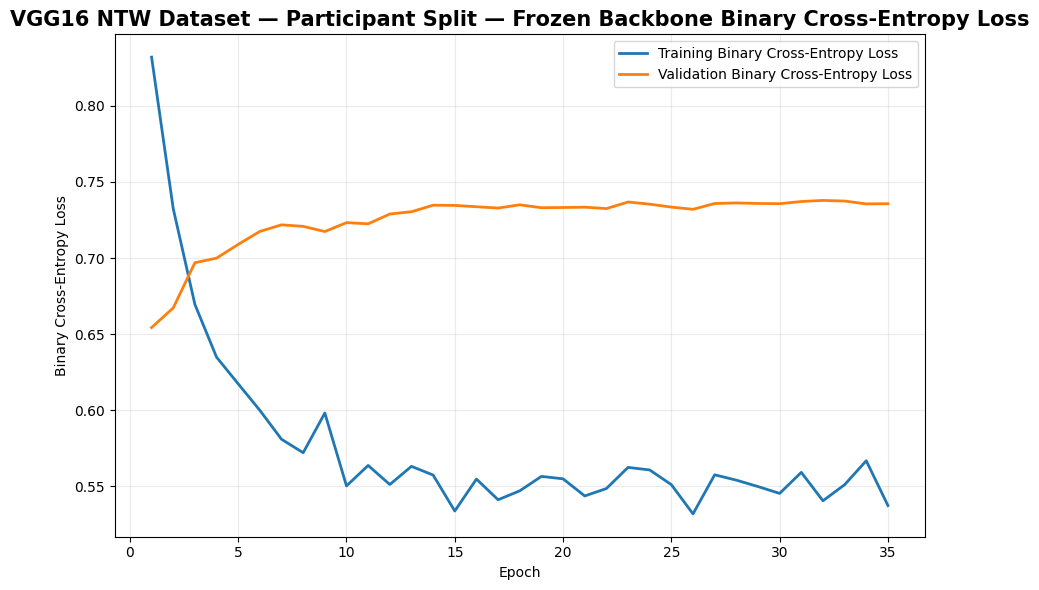

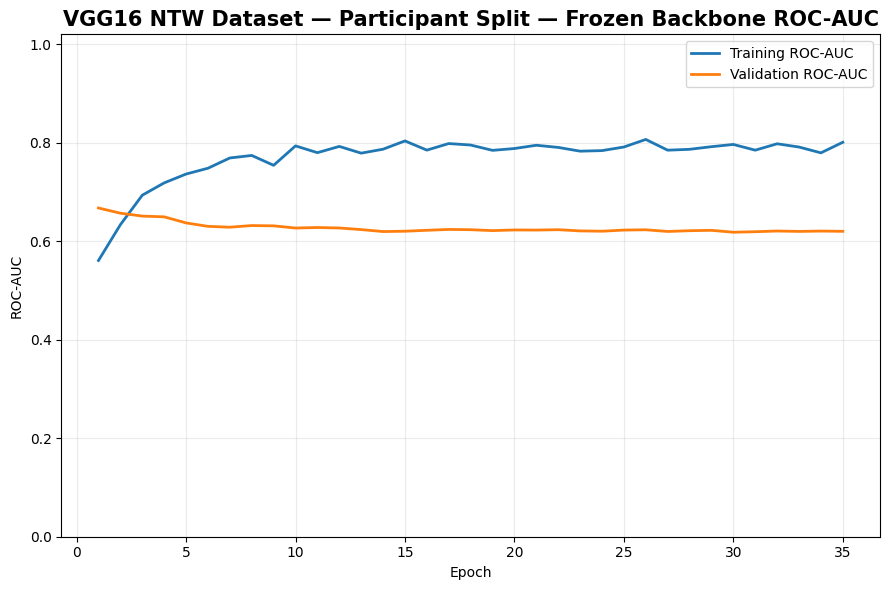

In [11]:
FROZEN_DIR = Path(SAVE_DIR) / "VGG16_NTW_Participant_Frozen"
FROZEN_DIR.mkdir(parents=True, exist_ok=True)

frozen_model, frozen_backbone = build_vgg16_model("VGG16_NTW_Participant_Frozen")
frozen_backbone.trainable = False
compile_model(frozen_model, 1e-4)

save_summary(frozen_model, FROZEN_DIR / "model_summary.txt")
frozen_params = get_parameter_counts(frozen_model)
display(frozen_params)
frozen_params.to_csv(FROZEN_DIR / "parameter_counts.csv", index=False)

frozen_checkpoint = str(FROZEN_DIR / "best_model.keras")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        frozen_checkpoint,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(str(FROZEN_DIR / "training_log.csv")),
]

frozen_hist_obj = frozen_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FROZEN_EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

frozen_history = combine_histories(frozen_hist_obj)
save_history(frozen_history, FROZEN_DIR, "VGG16_NTW_Participant_Frozen")
plot_history(
    frozen_history,
    FROZEN_DIR,
    "VGG16 NTW Dataset — Participant Split — Frozen Backbone",
    "VGG16_NTW_Participant_Frozen",
)

frozen_model = keras.models.load_model(frozen_checkpoint)

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step


,Model,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,FN,TP,Test_Participants,Test_Slices
0,VGG16 NTW Dataset — Frozen Backbone,0.615385,0.583333,1.0,0.166667,0.736842,0.333333,1,5,0,7,13,520


,patient_id,source_dataset,class_name,label,participant_probability,number_of_slices,participant_prediction
0,sub-control032059,Tao_Wu,healthy_control,0,0.399772,40,0
1,sub-control032063,Tao_Wu,healthy_control,0,0.792951,40,1
2,sub-control032064,Tao_Wu,healthy_control,0,0.863484,40,1
3,sub-control032066,Tao_Wu,healthy_control,0,0.695792,40,1
4,sub-control032068,Tao_Wu,healthy_control,0,0.803572,40,1
5,sub-control032069,Tao_Wu,healthy_control,0,0.763659,40,1
6,sub-patient032032,NEUROCON,parkinson,1,0.814251,40,1
7,sub-patient032036,NEUROCON,parkinson,1,0.718618,40,1
8,sub-patient032043,NEUROCON,parkinson,1,0.630194,40,1
9,sub-patient032050,NEUROCON,parkinson,1,0.758958,40,1


                 precision    recall  f1-score   support

Healthy Control     1.0000    0.1667    0.2857         6
      Parkinson     0.5833    1.0000    0.7368         7

       accuracy                         0.6154        13
      macro avg     0.7917    0.5833    0.5113        13
   weighted avg     0.7756    0.6154    0.5286        13



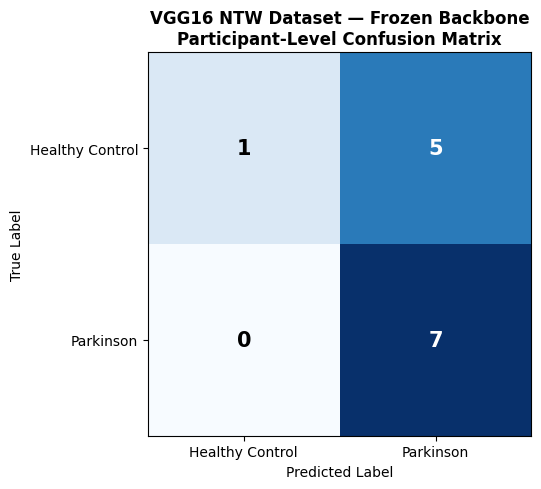

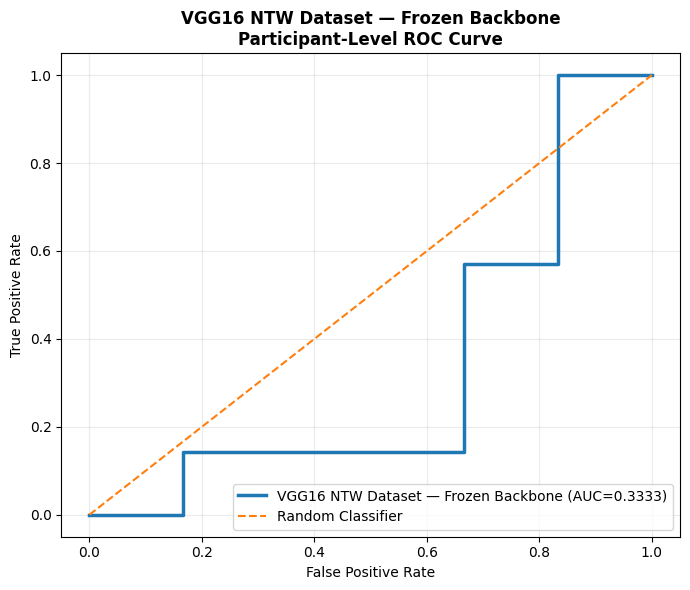

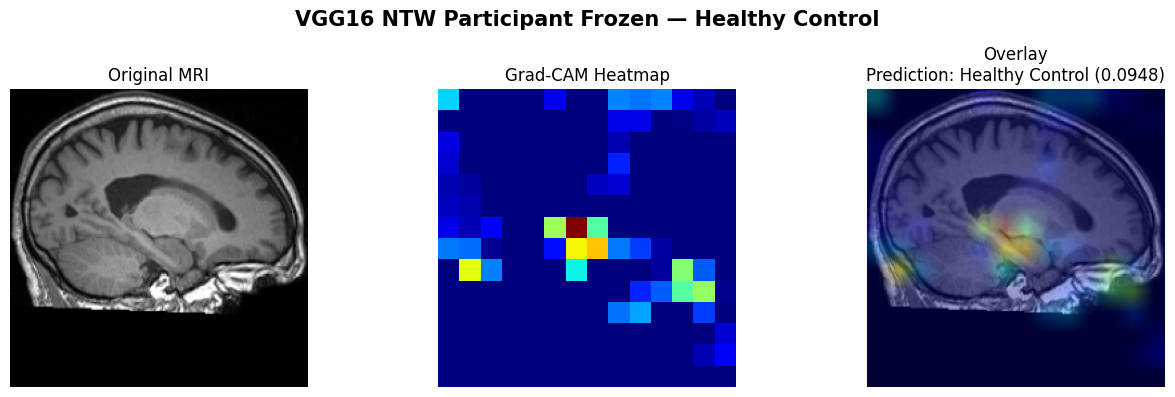

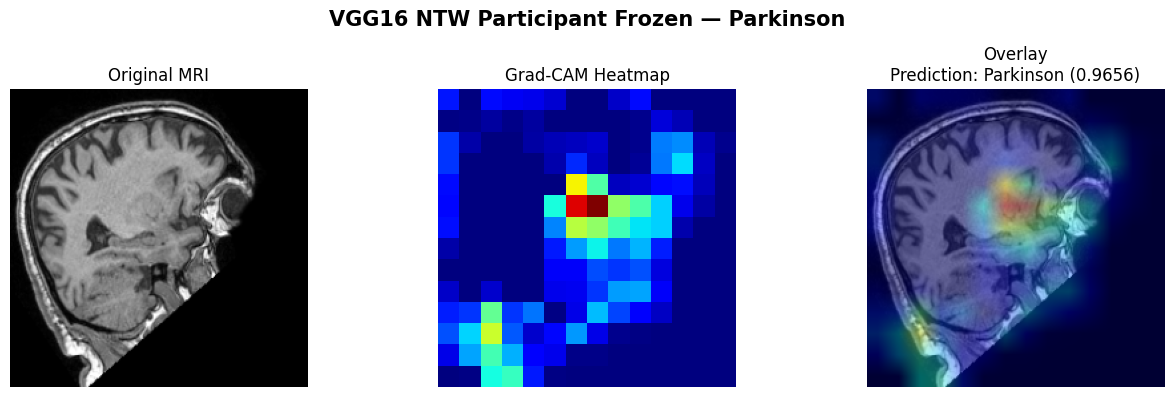

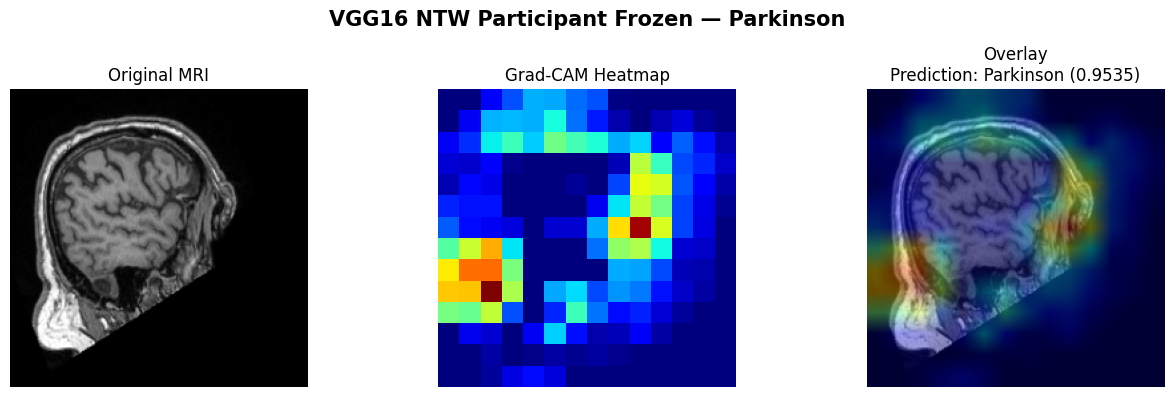

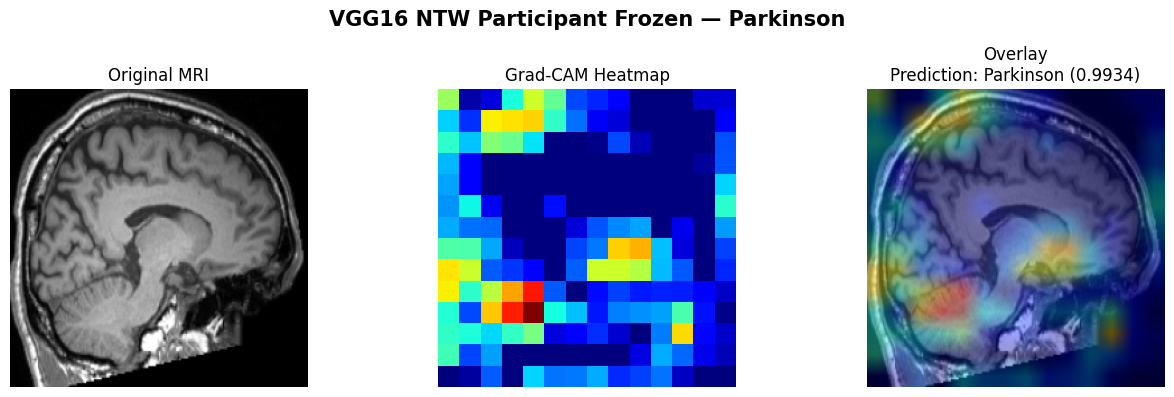

In [12]:
(
    frozen_metrics,
    frozen_slice_results,
    frozen_participant_results,
) = evaluate_participant_model(
    frozen_model,
    test_ds,
    test_df,
    FROZEN_DIR,
    "VGG16 NTW Dataset — Frozen Backbone",
    "VGG16_NTW_Participant_Frozen",
)

generate_participant_gradcams(
    frozen_model,
    frozen_slice_results,
    frozen_participant_results,
    FROZEN_DIR,
    "VGG16_NTW_Participant_Frozen",
)

## Experiment 2 — Fine-Tuned VGG16 Backbone

Epoch 1/10
144/145 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5307 - auc: 0.5424 - loss: 0.8433
Epoch 1: val_auc improved from None to 0.67215, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_NTW_patient_level/VGG16_NTW_patient_level_data_save_here/VGG16_NTW_Participant_FineTuned/warmup_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_NTW_patient_level/VGG16_NTW_patient_level_data_save_here/VGG16_NTW_Participant_FineTuned/warmup_best.keras
145/145 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - accuracy: 0.5483 - auc: 0.5674 - loss: 0.8108 - val_accuracy: 0.5750 - val_auc: 0.6722 - val_loss: 0.6485 - learning_rate: 1.0000e-04
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5859 - auc: 0.6239 - loss: 0.7395
Epoch 2: val_auc improved from 0.67215 to 0.70345, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parki

Model: "VGG16_NTW_Participant_FineTuned"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mri_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)    │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 256)            │       131,328 │
├─────────────────────────────────┼

,model,total_parameters,trainable_parameters,non_trainable_parameters
0,VGG16_NTW_Participant_FineTuned,14848321,13111809,1736512


Epoch 11/35
144/145 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6507 - auc: 0.7077 - loss: 0.6507
Epoch 11: val_auc improved from None to 0.64343, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_NTW_patient_level/VGG16_NTW_patient_level_data_save_here/VGG16_NTW_Participant_FineTuned/best_model.keras

Epoch 11: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_NTW_patient_level/VGG16_NTW_patient_level_data_save_here/VGG16_NTW_Participant_FineTuned/best_model.keras
145/145 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.6534 - auc: 0.7043 - loss: 0.6514 - val_accuracy: 0.5771 - val_auc: 0.6434 - val_loss: 0.6961 - learning_rate: 5.0000e-06
Epoch 12/35
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7007 - auc: 0.7668 - loss: 0.5802
Epoch 12: val_auc did not improve from 0.64343
145/145 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.7026 - auc: 0.7695 - 

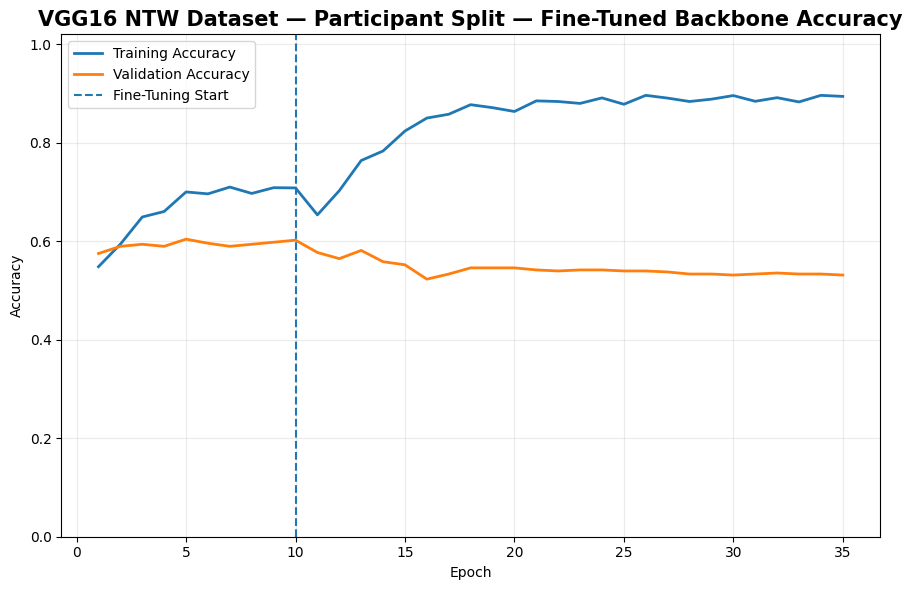

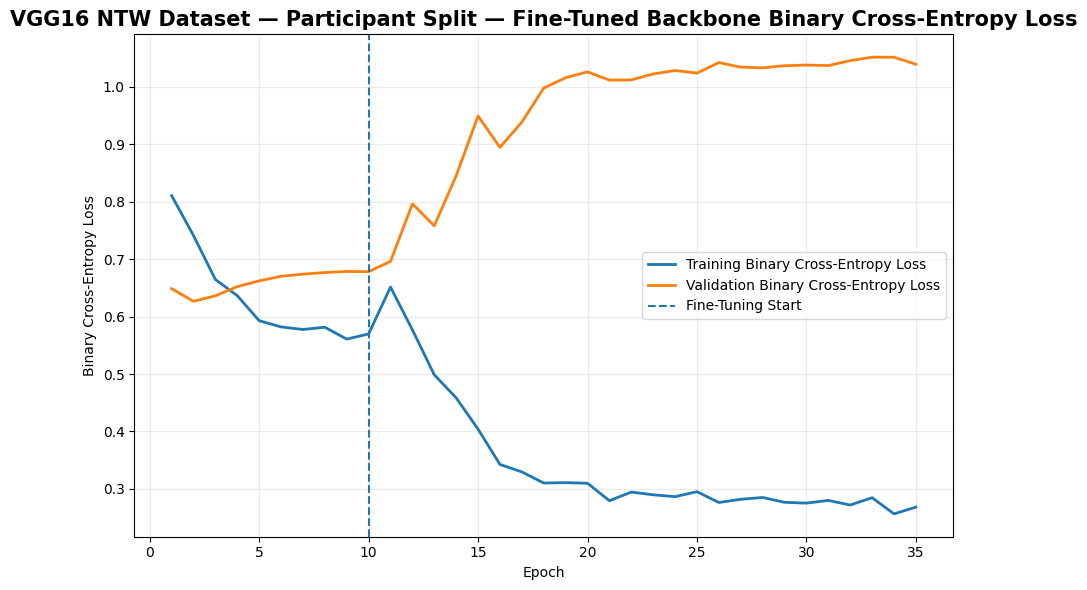

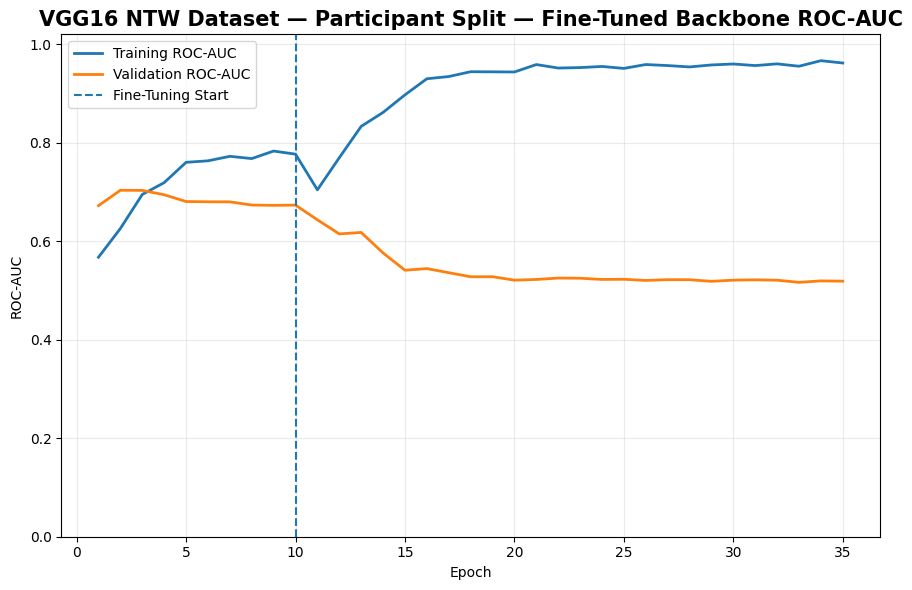

In [13]:
FINETUNED_DIR = Path(SAVE_DIR) / "VGG16_NTW_Participant_FineTuned"
FINETUNED_DIR.mkdir(parents=True, exist_ok=True)

ft_model, ft_backbone = build_vgg16_model("VGG16_NTW_Participant_FineTuned")

# Stage 1: frozen warm-up
ft_backbone.trainable = False
compile_model(ft_model, 1e-4)

warmup_checkpoint = str(FINETUNED_DIR / "warmup_best.keras")

warmup_callbacks = [
    keras.callbacks.ModelCheckpoint(
        warmup_checkpoint,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

warmup_hist = ft_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    verbose=1,
)

ft_model = keras.models.load_model(warmup_checkpoint)
ft_backbone = get_backbone(ft_model)

# Stage 2: partial fine-tuning
ft_backbone.trainable = True

for layer in ft_backbone.layers[:-FINE_TUNE_LAST_LAYERS]:
    layer.trainable = False

for layer in ft_backbone.layers[-FINE_TUNE_LAST_LAYERS:]:
    layer.trainable = True

compile_model(ft_model, 5e-6)

save_summary(ft_model, FINETUNED_DIR / "model_summary.txt")
ft_params = get_parameter_counts(ft_model)
display(ft_params)
ft_params.to_csv(FINETUNED_DIR / "parameter_counts.csv", index=False)

ft_checkpoint = str(FINETUNED_DIR / "best_model.keras")

ft_callbacks = [
    keras.callbacks.ModelCheckpoint(
        ft_checkpoint,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(str(FINETUNED_DIR / "training_log.csv")),
]

finetune_hist = ft_model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=WARMUP_EPOCHS,
    epochs=WARMUP_EPOCHS + FINE_TUNE_EPOCHS,
    callbacks=ft_callbacks,
    verbose=1,
)

ft_history = combine_histories(warmup_hist, finetune_hist)
save_history(ft_history, FINETUNED_DIR, "VGG16_NTW_Participant_FineTuned")
plot_history(
    ft_history,
    FINETUNED_DIR,
    "VGG16 NTW Dataset — Participant Split — Fine-Tuned Backbone",
    "VGG16_NTW_Participant_FineTuned",
    fine_tune_start=WARMUP_EPOCHS,
)

ft_model = keras.models.load_model(ft_checkpoint)

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step


,Model,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,FN,TP,Test_Participants,Test_Slices
0,VGG16 NTW Dataset — Fine-Tuned Backbone,0.615385,0.583333,1.0,0.166667,0.736842,0.761905,1,5,0,7,13,520


,patient_id,source_dataset,class_name,label,participant_probability,number_of_slices,participant_prediction
0,sub-control032059,Tao_Wu,healthy_control,0,0.440450,40,0
1,sub-control032063,Tao_Wu,healthy_control,0,0.601104,40,1
2,sub-control032064,Tao_Wu,healthy_control,0,0.607115,40,1
3,sub-control032066,Tao_Wu,healthy_control,0,0.815319,40,1
4,sub-control032068,Tao_Wu,healthy_control,0,0.524314,40,1
5,sub-control032069,Tao_Wu,healthy_control,0,0.857820,40,1
6,sub-patient032032,NEUROCON,parkinson,1,0.879851,40,1
7,sub-patient032036,NEUROCON,parkinson,1,0.621121,40,1
8,sub-patient032043,NEUROCON,parkinson,1,0.702194,40,1
9,sub-patient032050,NEUROCON,parkinson,1,0.894046,40,1


                 precision    recall  f1-score   support

Healthy Control     1.0000    0.1667    0.2857         6
      Parkinson     0.5833    1.0000    0.7368         7

       accuracy                         0.6154        13
      macro avg     0.7917    0.5833    0.5113        13
   weighted avg     0.7756    0.6154    0.5286        13



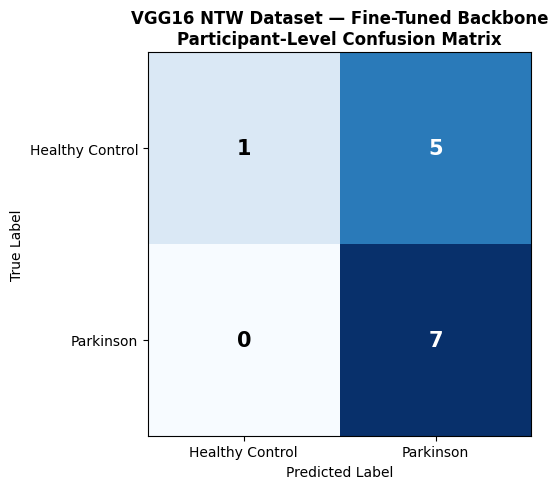

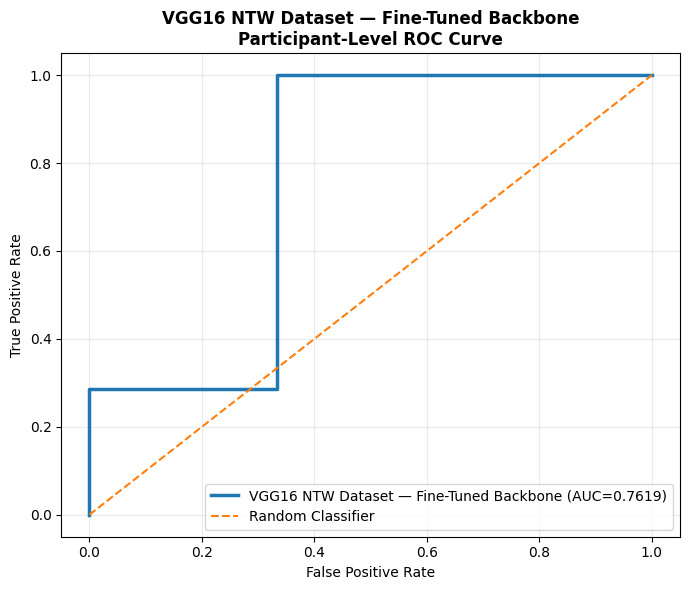

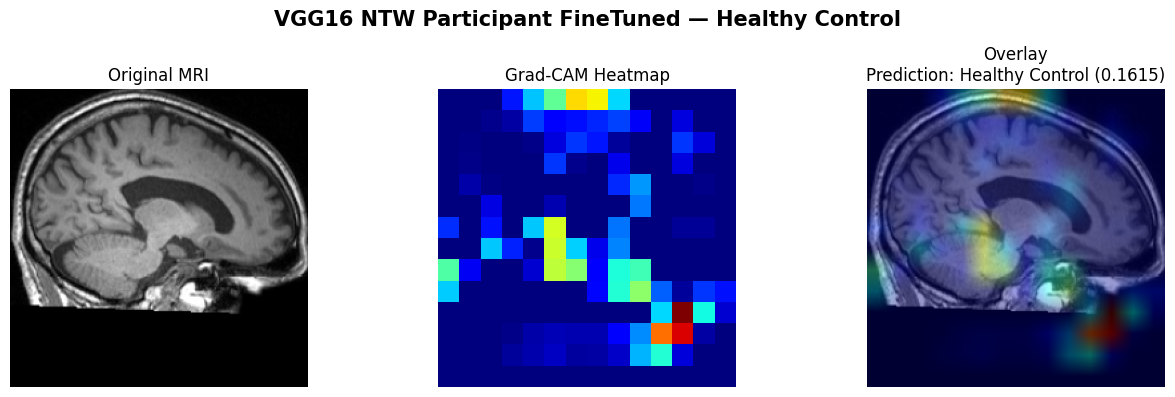

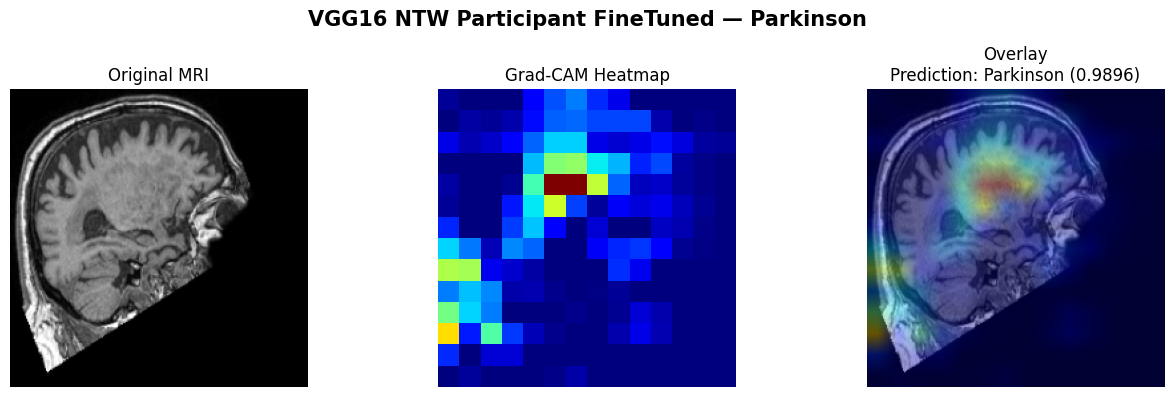

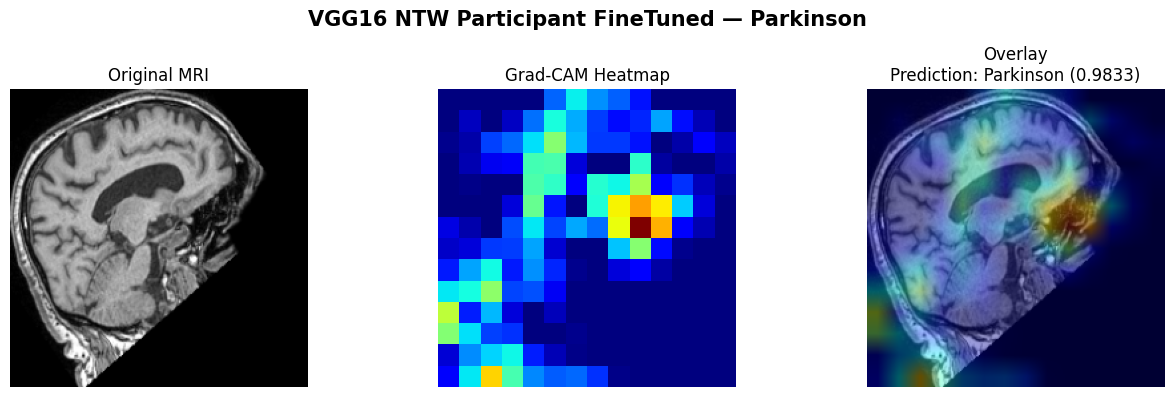

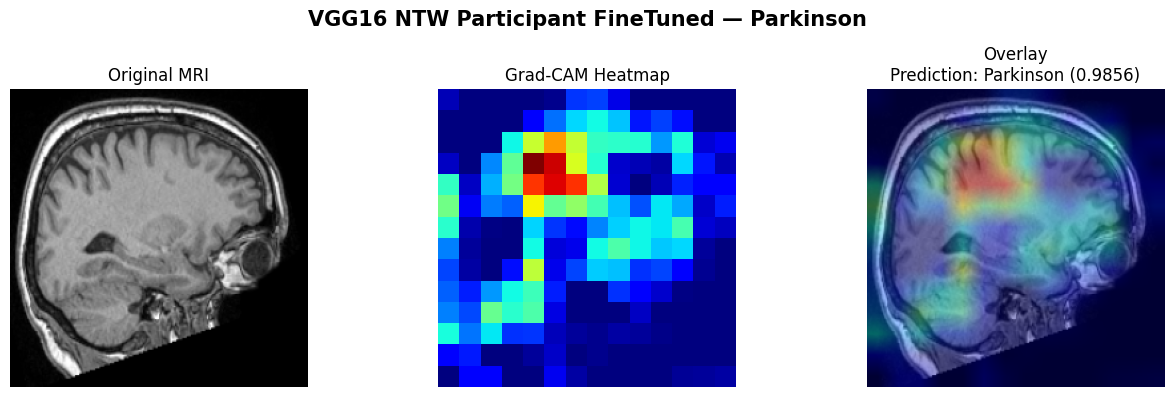

In [14]:
(
    ft_metrics,
    ft_slice_results,
    ft_participant_results,
) = evaluate_participant_model(
    ft_model,
    test_ds,
    test_df,
    FINETUNED_DIR,
    "VGG16 NTW Dataset — Fine-Tuned Backbone",
    "VGG16_NTW_Participant_FineTuned",
)

generate_participant_gradcams(
    ft_model,
    ft_slice_results,
    ft_participant_results,
    FINETUNED_DIR,
    "VGG16_NTW_Participant_FineTuned",
)

In [15]:
# =========================
# FINAL COMPARISON
# =========================
comparison = pd.DataFrame([frozen_metrics, ft_metrics])

display(comparison[[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1_Score",
    "ROC_AUC",
    "Test_Participants",
    "Test_Slices",
]])

comparison.to_csv(
    Path(SAVE_DIR) / "VGG16_NTW_Participant_Frozen_vs_FineTuned.csv",
    index=False,
)

print("Finished. Results saved in:", SAVE_DIR)

,Model,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,Test_Participants,Test_Slices
0,VGG16 NTW Dataset — Frozen Backbone,0.615385,0.583333,1.0,0.166667,0.736842,0.333333,13,520
1,VGG16 NTW Dataset — Fine-Tuned Backbone,0.615385,0.583333,1.0,0.166667,0.736842,0.761905,13,520


Finished. Results saved in: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Single_models_files/VGG16_NTW_patient_level/VGG16_NTW_patient_level_data_save_here
